#### Import Libraries

In [1]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_validate, KFold
import time

#### Import Datasets

In [2]:
%store -r X_train
%store -r X_test

%store -r y_train 
%store -r y_test

%store -r X_Scaled
%store -r X_test_Scaled

%store -r milling_df
%store -r X_resampled
%store -r y_resampled

#### Support Vector Machine

In [12]:
# Πιθανοί Kernels
kernels = ['linear', 'rbf']

# Τιμές για το C
C_space = [0.01, 0.1, 1, 10, 100]

# Τιμές για το γ
gamma_space = [0.01, 0.1, 1, 10]

# Create the parameter grid
param_grid = {'C': C_space, 'kernel': kernels, 'gamma': gamma_space}

y_resampled_array = y_resampled.values.ravel()

# Create the SVM model
svm = SVC()

# Δημιουργία του gridsearch για εύρεση C και Kernel βάσει f1 score σε κάθε fold
grid_search = GridSearchCV(svm, param_grid=param_grid, cv=5,
                           n_jobs=-1, scoring='f1_macro', verbose=2)

grid_search.fit(X_Scaled, y_resampled_array)

print("Best Parameters:")
print(grid_search.best_params_)

# Print the best score
print(f"Best Score: {grid_search.best_score_:.4f}")

svm_best_model = grid_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=   8.9s
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=   8.9s
[CV] END ...................C=0.01, gamma=0.1, kernel=linear; total time=   9.3s
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=   9.6s
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=  10.1s
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=  10.2s
[CV] END ...................C=0.01, gamma=0.1, kernel=linear; total time=  10.9s
[CV] END ...................C=0.01, gamma=0.1, kernel=linear; total time=   8.5s
[CV] END ...................C=0.01, gamma=0.1, kernel=linear; total time=   8.4s
[CV] END ...................C=0.01, gamma=0.1, kernel=linear; total time=   8.9s
[CV] END .....................C=0.01, gamma=1, kernel=linear; total time=   8.9s
[CV] END .....................C=0.01, gamma=1, 

In [3]:
svm_best_model = SVC(
    C=100,
    gamma=10,
    kernel='rbf',
    probability=True
)

y_resampled_array = y_resampled.values.ravel()

start = time.time()
svm_best_model.fit(X_Scaled, y_resampled_array)
end_train = time.time()

#### Evaluation on Training Data

In [4]:
y_pred_train = svm_best_model.predict(X_Scaled)
y_train = np.array(y_resampled_array) 
y_train_pred_proba = svm_best_model.predict_proba(X_Scaled)

# Classification Report
class_report = classification_report(y_train, y_pred_train)
print(class_report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)
print("Train Confusion Matrix:")
print(conf_matrix)

# Accuracy
accuracy = accuracy_score(y_train, y_pred_train)
print(f"\nTrain Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_train, y_pred_train, average='weighted')
print(f"Train Precision: {precision:.4f}")

# Recall
recall = recall_score(y_train, y_pred_train, average='weighted')
print(f"Train Recall: {recall:.4f}")

# F1-score
f1 = f1_score(y_train, y_pred_train, average='weighted')
print(f"Train F1-score: {f1:.4f}\n")

# Calculate the ROC AUC score for each class
roc_auc_dict = {}
for i in range(y_train_pred_proba.shape[1]):
    fpr, tpr, _ = roc_curve(y_train, y_train_pred_proba[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    roc_auc_dict[i] = roc_auc  

print("ROC AUC scores for each class:")
for i, score in roc_auc_dict.items():
    print(f"Class {i}: {score:.4f}")

# Calculate the overall ROC AUC score
roc_auc = roc_auc_score(y_train, y_train_pred_proba, multi_class='ovr', average='weighted')
print(f"Overall Test ROC AUC Score: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4817
           1       1.00      1.00      1.00      4810
           2       1.00      1.00      1.00      4822
           3       1.00      1.00      1.00      4818
           4       1.00      1.00      1.00      4819

    accuracy                           1.00     24086
   macro avg       1.00      1.00      1.00     24086
weighted avg       1.00      1.00      1.00     24086

Train Confusion Matrix:
[[4817    0    0    0    0]
 [   0 4804    0    0    6]
 [   0    0 4822    0    0]
 [   0    0    0 4818    0]
 [   0    0    0    0 4819]]

Train Accuracy: 0.9998
Train Precision: 0.9998
Train Recall: 0.9998
Train F1-score: 0.9998

ROC AUC scores for each class:
Class 0: 1.0000
Class 1: 0.9999
Class 2: 1.0000
Class 3: 1.0000
Class 4: 0.9999
Overall Test ROC AUC Score: 1.0000


#### Evaluation on Test Data

In [5]:
start_predict = time.time()
y_pred_test = svm_best_model.predict(X_test_Scaled)
end_predict = time.time()

y_test = np.array(y_test)  
y_test_pred_proba = svm_best_model.predict_proba(X_test_Scaled)

# Classification Report
svm_class_report = classification_report(y_test, y_pred_test)
print(svm_class_report)
svm_class_report = classification_report(y_test, y_pred_test, output_dict=True)

# Confusion Matrix
svm_conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Test Confusion Matrix:")
print(svm_conf_matrix)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTest Accuracy: {svm_accuracy:.4f}")

# Precision
svm_precision = precision_score(y_test, y_pred_test, average='weighted')
print(f"Test Precision: {svm_precision:.4f}")

# Recall
svm_recall = recall_score(y_test, y_pred_test, average='weighted')
print(f"Test Recall: {svm_recall:.4f}")

# F1-score
svm_f1 = f1_score(y_test, y_pred_test, average='weighted')
print(f"Test F1-score: {svm_f1:.4f}\n")

# Calculate the ROC AUC score for each class
svm_roc_auc_dict = {}
for i in range(y_test_pred_proba.shape[1]):
    fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba[:, i], pos_label=i)
    svm_roc_auc = auc(fpr, tpr)
    svm_roc_auc_dict[i] = svm_roc_auc  

print("ROC AUC scores for each class:")
for i, score in svm_roc_auc_dict.items():
    print(f"Class {i}: {score:.4f}")

# Calculate the overall ROC AUC score
svm_roc_auc = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', average='weighted')
print(f"Overall Test ROC AUC Score: {svm_roc_auc:.4f}\n")

svm_training_time = end_train - start
print(f"Random Forest Training Time: {svm_training_time:.5f}")
svm_prediction_time = end_predict - start_predict
print(f"Random Forest Prediction Time: {svm_prediction_time:.5f}")

              precision    recall  f1-score   support

           0       0.58      0.65      0.61        51
           1       0.99      0.98      0.98      4830
           2       0.69      0.65      0.67        37
           3       0.55      0.48      0.51        54
           4       0.06      0.21      0.09        19

    accuracy                           0.96      4991
   macro avg       0.57      0.59      0.57      4991
weighted avg       0.97      0.96      0.97      4991

Test Confusion Matrix:
[[  33   18    0    0    0]
 [  20 4717    8   20   65]
 [   4    8   24    1    0]
 [   0   26    2   26    0]
 [   0   14    1    0    4]]

Test Accuracy: 0.9625
Test Precision: 0.9716
Test Recall: 0.9625
Test F1-score: 0.9668

ROC AUC scores for each class:
Class 0: 0.9832
Class 1: 0.9276
Class 2: 0.9543
Class 3: 0.9770
Class 4: 0.6942
Overall Test ROC AUC Score: 0.9280

Random Forest Training Time: 8.85240
Random Forest Prediction Time: 0.30155


### Plot the Results

#### Confusion Matrix

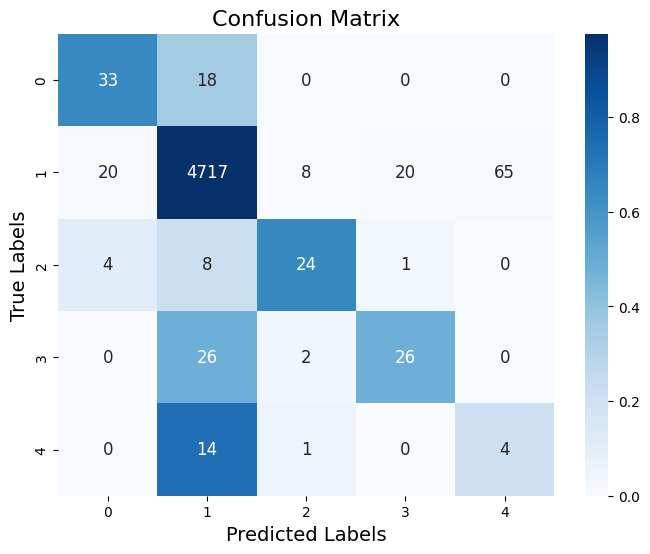

In [6]:
conf_matrix_normalized = svm_conf_matrix.astype(float) /  svm_conf_matrix.sum(axis=1)[:, np.newaxis]
conf_matrix_df = pd.DataFrame(svm_conf_matrix, index= svm_best_model.classes_, columns=svm_best_model.classes_)
conf_matrix_normalized_df = pd.DataFrame(conf_matrix_normalized, index=svm_best_model.classes_, columns=svm_best_model.classes_)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    conf_matrix_normalized_df, 
    annot=conf_matrix_df.values,  
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=svm_best_model.classes_,
    yticklabels=svm_best_model.classes_,
    annot_kws={"size": 12}  
)

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

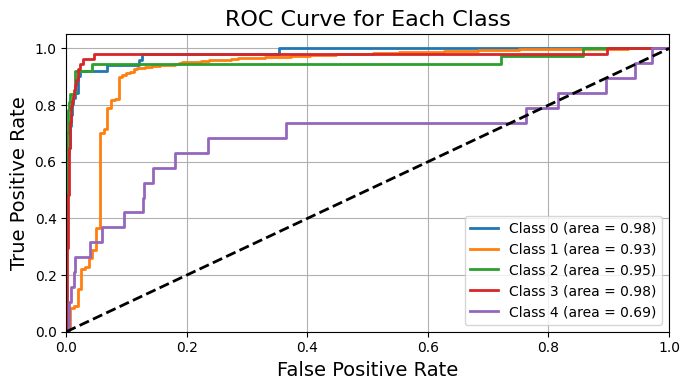

In [7]:
y_test_bin = label_binarize(y_test, classes=svm_best_model.classes_)
n_classes = y_test_bin.shape[1]
plt.figure(figsize=(7, 4))

# Plot ROC curve for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
    rf_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {svm_best_model.classes_[i]} (area = {rf_roc_auc:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Each Class', fontsize=16)
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Accuracy, Precision, Recall, F1 Score

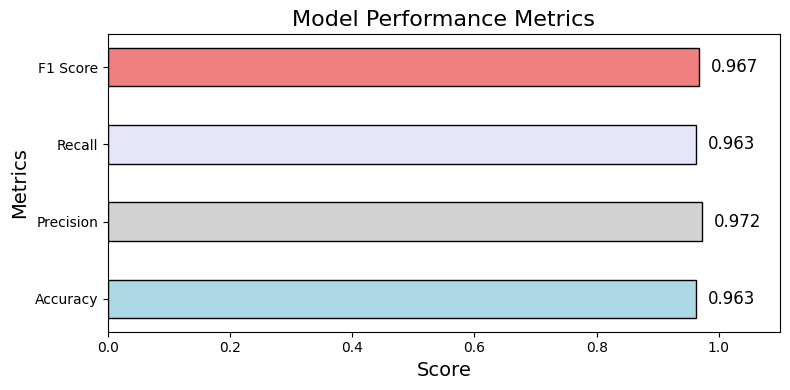

In [8]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [svm_accuracy, svm_precision, svm_recall, svm_f1]

# Define a color palette
colors = ['#ADD8E6', '#D3D3D3', '#E6E6FA', '#F08080']

plt.figure(figsize=(8,4))
bar_width = 0.5 
bars = plt.barh(metrics, values, height=bar_width, color=colors, edgecolor='black')

for bar in bars:
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2.0, f"{bar.get_width():.3f}", ha='left', va='center', fontsize=12)

plt.xlabel('Score', fontsize=14)
plt.ylabel('Metrics', fontsize=14)
plt.title('Model Performance Metrics', fontsize=16)
plt.xlim(0, 1.1) 
plt.tight_layout()
plt.show()

### Random Forest Algorithm with 5fold Cross Validation

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
svm_5cross = SVC(
    C=100,
    gamma=10,
    kernel='rbf',
    probability=True
)

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(svm_5cross, X_Scaled, y_resampled_array, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--"*100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 0.9954337899543378
Precision: 0.9954513148432056
Recall: 0.9954337899543378
F1 Score: 0.9954194486939227
Log Loss: 0.018320501899167656
ROC AUC: 0.9993515721092948
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9952252439277559
Precision: 0.9952564277620526
Recall: 0.9952252439277559
F1 Score: 0.9952104688751124
Log Loss: 0.027897408967878096
ROC AUC: 0.9988135226959451
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9954328420178534
Precision: 0.9954681676377516
Recall: 0.9954328420178534
F1 Score: 0.9954214937216764
Log Loss: 0.014301197439165157
ROC AUC: 0.9996484945442159
----------------------------

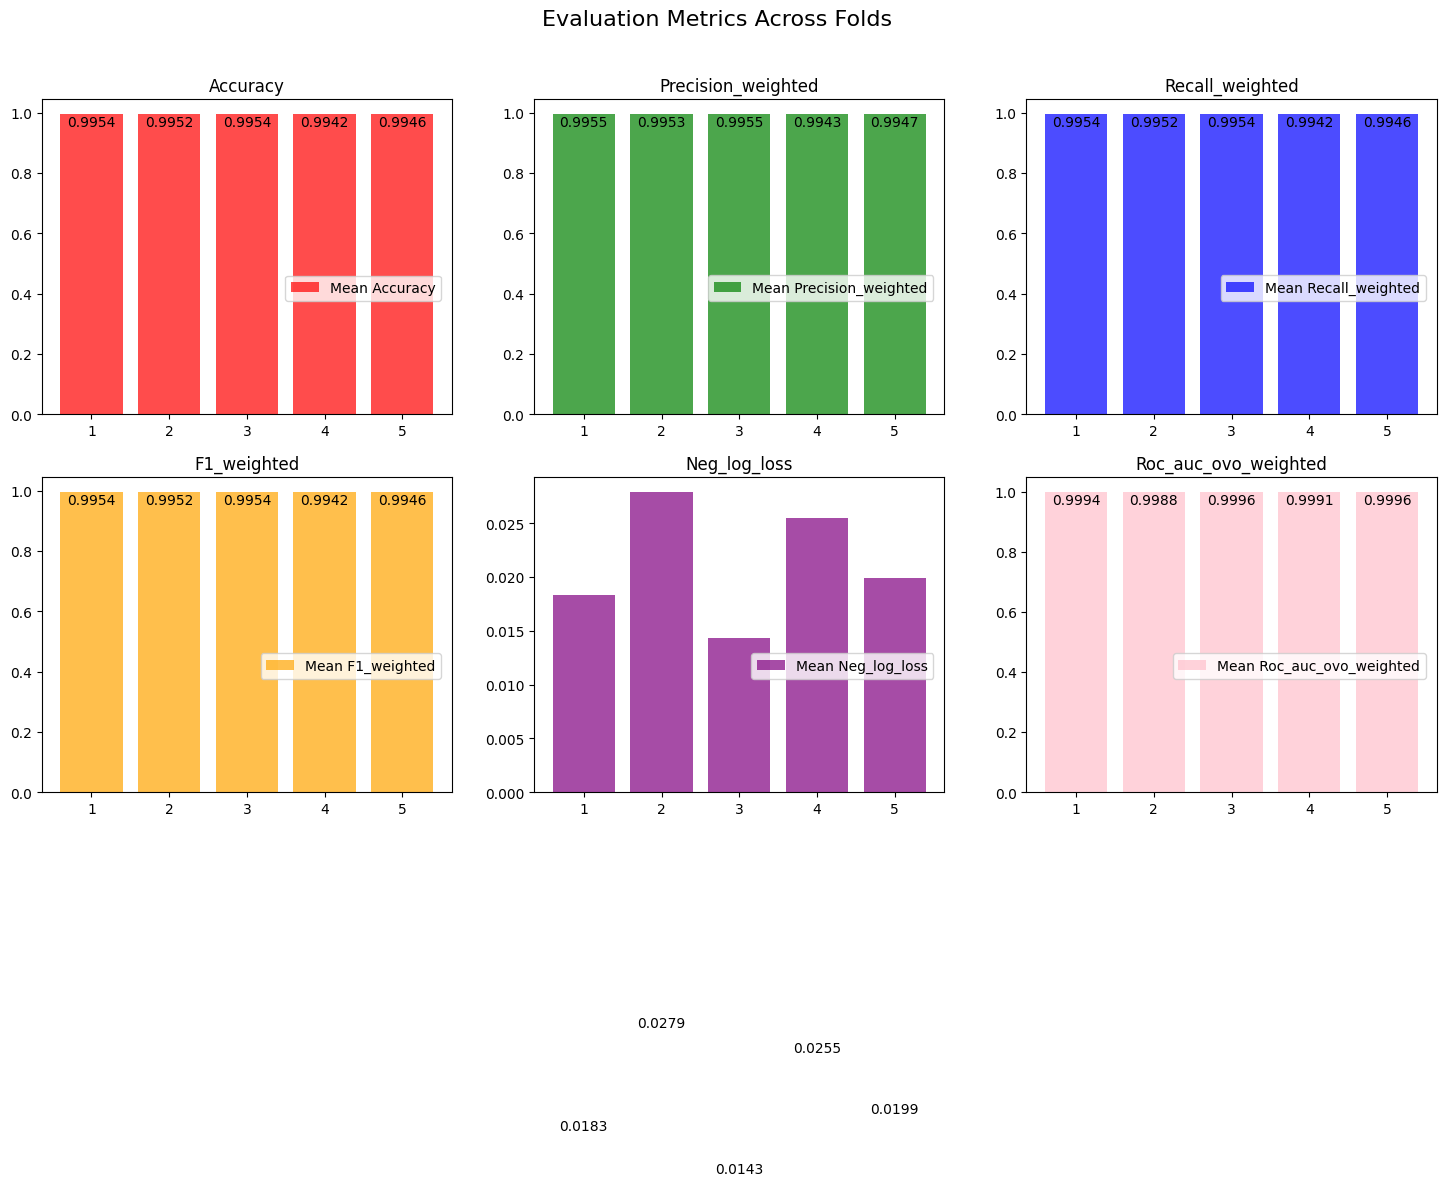

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function για τς τιμές μέσα στις μπάρες
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()

In [11]:
# Store all metrics
%store svm_class_report
%store svm_conf_matrix
%store svm_accuracy
%store svm_precision
%store svm_recall
%store svm_f1
%store svm_roc_auc_dict
%store svm_roc_auc
%store svm_training_time
%store svm_prediction_time

Stored 'svm_class_report' (dict)
Stored 'svm_conf_matrix' (ndarray)
Stored 'svm_accuracy' (float)
Stored 'svm_precision' (float64)
Stored 'svm_recall' (float64)
Stored 'svm_f1' (float64)
Stored 'svm_roc_auc_dict' (dict)
Stored 'svm_roc_auc' (float64)
Stored 'svm_training_time' (float)
Stored 'svm_prediction_time' (float)
